In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
df= pd.read_csv('LA_AQS_2023.csv')

In [3]:
df.head()

,State Code,County Code,Site Number,Parameter Code,POC,Latitude,Longitude,Datum,Parameter Name,Duration Description,...,AQI,Daily Criteria Indicator,Tribe Name,State Name,County Name,City Name,Local Site Name,Address,MSA or CBSA Name,Data Source
0,6,37,1103,68103,1,34.06659,-118.22688,WGS84,Ambient Min Temperature,24 HOUR,...,.,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart
1,6,37,1103,42602,3,34.06659,-118.22688,WGS84,Nitrogen dioxide (NO2),1 HOUR,...,16,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart
2,6,37,1103,62201,1,34.06659,-118.22688,WGS84,Relative Humidity,1 HOUR,...,.,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart
3,6,37,1103,62101,1,34.06659,-118.22688,WGS84,Outdoor Temperature,1 HOUR,...,.,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart
4,6,37,1103,42603,1,34.06659,-118.22688,WGS84,Oxides of nitrogen (NOx),1 HOUR,...,.,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart


In [4]:
col_names = df.columns.tolist()

print("Column Names:", col_names)

Column Names: ['State Code', 'County Code', 'Site Number', 'Parameter Code', 'POC', 'Latitude', 'Longitude', 'Datum', 'Parameter Name', 'Duration Description', 'Pollutant Standard', 'Date (Local)', 'Year', 'Day In Year (Local)', 'Units of Measure', 'Exceptional Data Type', 'Nonreg Observation Count', 'Observation Count', 'Observation Percent', 'Nonreg Arithmetic Mean', 'Arithmetic Mean', 'Nonreg First Maximum Value', 'First Maximum Value', 'First Maximum Hour', 'AQI', 'Daily Criteria Indicator', 'Tribe Name', 'State Name', 'County Name', 'City Name', 'Local Site Name', 'Address', 'MSA or CBSA Name', 'Data Source']


In [5]:
sorted_names = sorted(df['Parameter Name'].dropna().unique())

print("--- Alphabetical List of Parameters ---")
for name in sorted_names:
    print(f"- {name}")

--- Alphabetical List of Parameters ---
- Acceptable PM2.5 AQI & Speciation Mass
- Acenaphthene (TSP) STP
- Acenaphthylene (TSP) STP
- Acetaldehyde
- Aluminum PM2.5 LC
- Ambient Max Temperature
- Ambient Min Temperature
- Ammonium Ion PM2.5 LC
- Anthracene (TSP) STP
- Antimony (TSP) STP
- Antimony PM2.5 LC
- Arsenic (TSP) STP
- Arsenic PM10 LC
- Arsenic PM2.5 LC
- Average Ambient Pressure
- Average Ambient Pressure for URG3000N
- Average Ambient Temperature
- Average Ambient Temperature for URG3000N
- Barium PM2.5 LC
- Barometric pressure
- Benzo[a]anthracene (TSP) STP
- Benzo[a]pyrene (TSP) STP
- Benzo[b]fluoranthene (TSP) STP
- Benzo[e]pyrene (TSP) STP
- Benzo[g,h,i]perylene (TSP) STP
- Benzo[k]fluoranthene (TSP) STP
- Beryllium (TSP) STP
- Beryllium PM10 LC
- Bromine PM2.5 LC
- Butyraldehyde
- Cadmium (TSP) STP
- Cadmium PM10 LC
- Cadmium PM2.5 LC
- Calcium PM2.5 LC
- Carbon monoxide
- Cerium PM2.5 LC
- Cesium PM2.5 LC
- Chloride PM10 STP
- Chloride PM2.5 LC
- Chlorine PM2.5 LC
- Ch

In [6]:
df_o3 = df[(df['Parameter Name']=='Ozone')& (df['Duration Description']=='1 HOUR')]
df_o3.head()

,State Code,County Code,Site Number,Parameter Code,POC,Latitude,Longitude,Datum,Parameter Name,Duration Description,...,AQI,Daily Criteria Indicator,Tribe Name,State Name,County Name,City Name,Local Site Name,Address,MSA or CBSA Name,Data Source
20,6,37,1103,44201,1,34.06659,-118.22688,WGS84,Ozone,1 HOUR,...,.,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart
64,6,37,1103,44201,1,34.06659,-118.22688,WGS84,Ozone,1 HOUR,...,.,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart
204,6,37,1103,44201,1,34.06659,-118.22688,WGS84,Ozone,1 HOUR,...,.,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart
228,6,37,1103,44201,1,34.06659,-118.22688,WGS84,Ozone,1 HOUR,...,.,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart
271,6,37,1103,44201,1,34.06659,-118.22688,WGS84,Ozone,1 HOUR,...,.,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart


In [7]:
df_o3.describe()

,State Code,County Code,Site Number,Parameter Code,POC,Latitude,Longitude,Year,Day In Year (Local),Nonreg Observation Count,Observation Count,Observation Percent,Nonreg Arithmetic Mean,Arithmetic Mean,Nonreg First Maximum Value,First Maximum Value,First Maximum Hour,Tribe Name
count,273.0,273.0,273.0,273.0,273.0,2.730000e+02,2.730000e+02,273.0,273.000000,0.0,273.000000,273.000000,0.0,273.000000,0.0,273.000000,273.000000,0.0
mean,6.0,37.0,1103.0,44201.0,1.0,3.406659e+01,-1.182269e+02,2023.0,137.000000,NaN,23.794872,99.161172,NaN,0.027899,NaN,0.051352,12.992674,NaN
std,0.0,0.0,0.0,0.0,0.0,1.708434e-13,7.403216e-13,0.0,78.952517,NaN,0.849984,3.508869,NaN,0.007559,NaN,0.013722,3.169237,NaN
min,6.0,37.0,1103.0,44201.0,1.0,3.406659e+01,-1.182269e+02,2023.0,1.000000,NaN,17.000000,71.000000,NaN,0.008333,NaN,0.019000,0.000000,NaN
25%,6.0,37.0,1103.0,44201.0,1.0,3.406659e+01,-1.182269e+02,2023.0,69.000000,NaN,24.000000,100.000000,NaN,0.023958,NaN,0.042000,12.000000,NaN
50%,6.0,37.0,1103.0,44201.0,1.0,3.406659e+01,-1.182269e+02,2023.0,137.000000,NaN,24.000000,100.000000,NaN,0.028458,NaN,0.049000,13.000000,NaN
75%,6.0,37.0,1103.0,44201.0,1.0,3.406659e+01,-1.182269e+02,2023.0,205.000000,NaN,24.000000,100.000000,NaN,0.032958,NaN,0.059000,14.000000,NaN
max,6.0,37.0,1103.0,44201.0,1.0,3.406659e+01,-1.182269e+02,2023.0,273.000000,NaN,24.000000,100.000000,NaN,0.045750,NaN,0.097000,23.000000,NaN


In [8]:
df_no2 = df[(df['Parameter Name']=='Nitrogen dioxide (NO2)')& (df['Duration Description']=='1 HOUR')]
df_no2.head()

,State Code,County Code,Site Number,Parameter Code,POC,Latitude,Longitude,Datum,Parameter Name,Duration Description,...,AQI,Daily Criteria Indicator,Tribe Name,State Name,County Name,City Name,Local Site Name,Address,MSA or CBSA Name,Data Source
1,6,37,1103,42602,3,34.06659,-118.22688,WGS84,Nitrogen dioxide (NO2),1 HOUR,...,16,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart
19,6,37,1103,42602,1,34.06659,-118.22688,WGS84,Nitrogen dioxide (NO2),1 HOUR,...,17,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart
29,6,37,1103,42602,1,34.06659,-118.22688,WGS84,Nitrogen dioxide (NO2),1 HOUR,...,17,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart
41,6,37,1103,42602,3,34.06659,-118.22688,WGS84,Nitrogen dioxide (NO2),1 HOUR,...,16,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart
44,6,37,1103,42602,3,34.06659,-118.22688,WGS84,Nitrogen dioxide (NO2),1 HOUR,...,20,Y,NaN,California,Los Angeles,Los Angeles,Los Angeles-North Main Street,"1630 N MAIN ST, LOS ANGELES","Los Angeles-Long Beach-Anaheim, CA",AQS Data Mart


In [9]:
o3_raw = df_o3['Units of Measure'].unique()
no2_raw = df_no2['Units of Measure'].unique()

print(f"Ozone (O3) units: {o3_raw[0] if len(o3_raw) > 0 else 'No Data'}")
print(f"NO2 units: {no2_raw[0] if len(no2_raw) > 0 else 'No Data'}")

Ozone (O3) units: Parts per million
NO2 units: Parts per billion


In [10]:
# Rename and select using your dataset's exact case-sensitive column names
o3 = df_o3.rename(columns={
    "Arithmetic Mean": "o3_ppb", 
    "First Maximum Value": "o3_max_ppb"
})[['Date (Local)', "o3_ppb", "o3_max_ppb"]].copy()

# Convert ppm -> ppb
o3["o3_ppb"] *= 1000      
o3["o3_max_ppb"] *= 1000

# Do the exact same for the NO2 dataframe
no2 = df_no2.rename(columns={
    "Arithmetic Mean": 'no2_ppb', 
    "First Maximum Value": "no2_max_ppb"
})[['Date (Local)', "no2_ppb", "no2_max_ppb"]].copy()

o3.head()

,Date (Local),o3_ppb,o3_max_ppb
20,2023-01-01,31.708,42.0
64,2023-01-02,15.792,28.0
204,2023-01-03,25.000,35.0
228,2023-01-04,20.500,31.0
271,2023-01-05,27.375,42.0


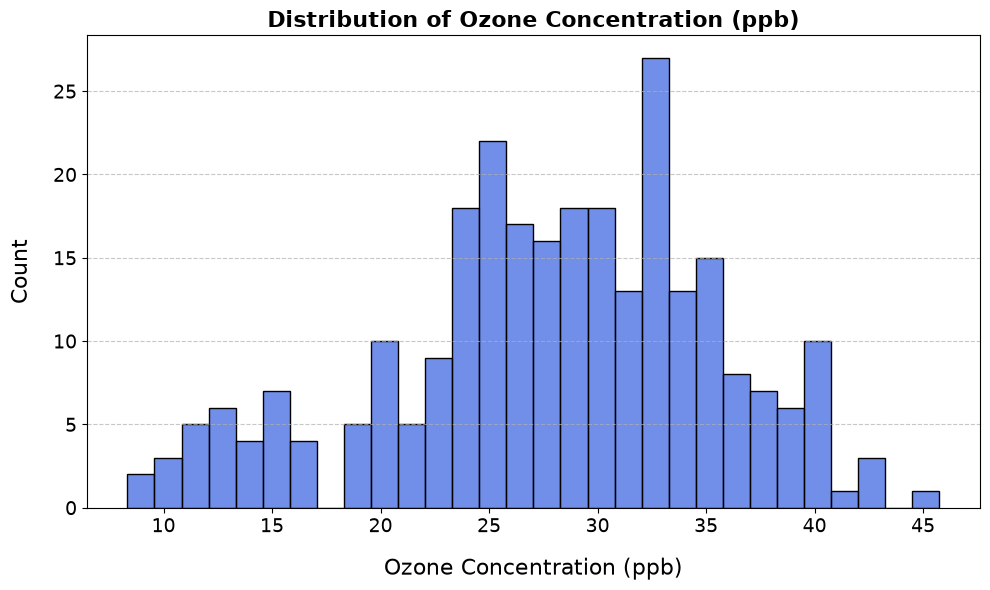

In [11]:
# Use the updated dataframe that is already converted to ppb
value_ozone_ppb = o3["o3_ppb"]

plt.figure(figsize=(10, 6))

sns.histplot(value_ozone_ppb, bins=30, color='royalblue', edgecolor='black')

# Updated labels to reflect the new ppb metric
plt.xlabel('Ozone Concentration (ppb)', fontsize=16, labelpad=15)
plt.ylabel('Count', fontsize=16, labelpad=15)
plt.title('Distribution of Ozone Concentration (ppb)', fontsize=16, fontweight='bold')
plt.tick_params(axis='both', which='major', labelsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7) # Added a subtle grid for better readability
plt.tight_layout() 

plt.show()

This plot shows histogram of the distribution of ozone concentration in ppb. This is the daily mean O3 collected in every hour. Look like 33 ppb occurs most frequently while 25-35 ppb is the most common range.

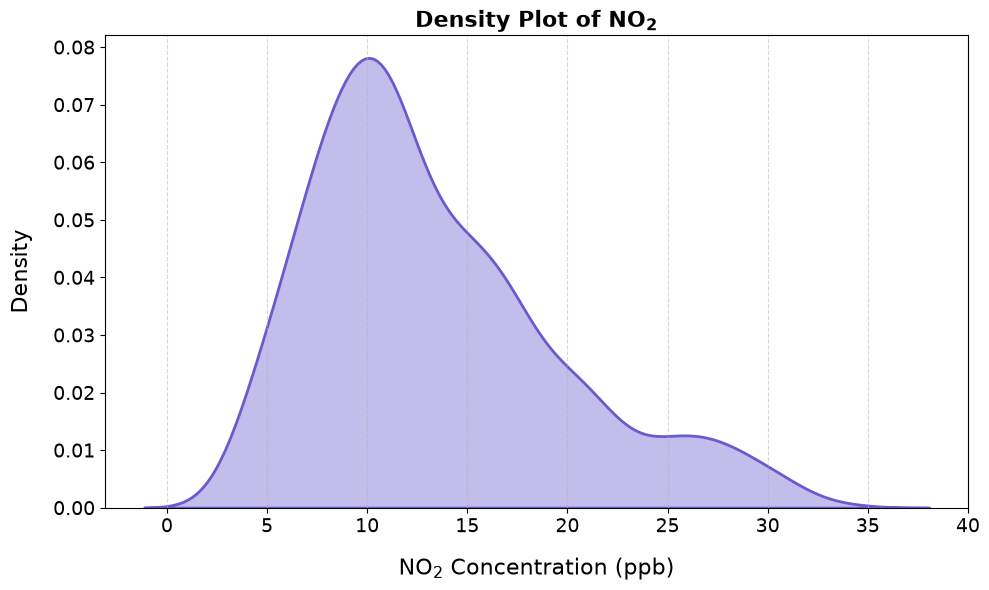

In [12]:
# Use your pre-processed no2 DataFrame column to ensure consistent data cleanup
value_no2_ppb = no2["no2_ppb"]

plt.figure(figsize=(10, 6))
# Maintained your sleek fill style with an updated alpha value for clean visibility
sns.kdeplot(value_no2_ppb, color='slateblue', fill=True, alpha=0.4, linewidth=2)

# Kept your beautifully formatted LaTeX sub/superscript styling intact
plt.xlabel(r"$\mathrm{NO_2}$ Concentration (ppb)", fontsize=16, labelpad=15)
plt.ylabel('Density', fontsize=16, labelpad=15)
plt.title(r'Density Plot of $\mathbf{NO_2}$', fontsize=16, fontweight='bold')
plt.tick_params(axis='both', which='major', labelsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.5) # Added vertical gridlines to track concentration markers easily
plt.tight_layout() 

plt.show()

This is the density plot of NO2 concentration in ppb, showing 10 ppb is the most dense or most frequent and a tailing towards high concentration.

In [13]:
# Merge o3 and no2 on their actual case-sensitive date column
df_no2_o3 = o3.merge(no2, how='inner', on='Date (Local)')

print(f"o3 alone: {len(o3)} days | no2 alone: {len(no2)} days | merged: {len(df_no2_o3)} days")
df_no2_o3.head()

o3 alone: 273 days | no2 alone: 1092 days | merged: 1092 days


,Date (Local),o3_ppb,o3_max_ppb,no2_ppb,no2_max_ppb
0,2023-01-01,31.708,42.0,4.816667,17.5
1,2023-01-01,31.708,42.0,4.550000,18.7
2,2023-01-01,31.708,42.0,4.550000,18.7
3,2023-01-01,31.708,42.0,4.816667,17.5
4,2023-01-02,15.792,28.0,14.720833,21.6


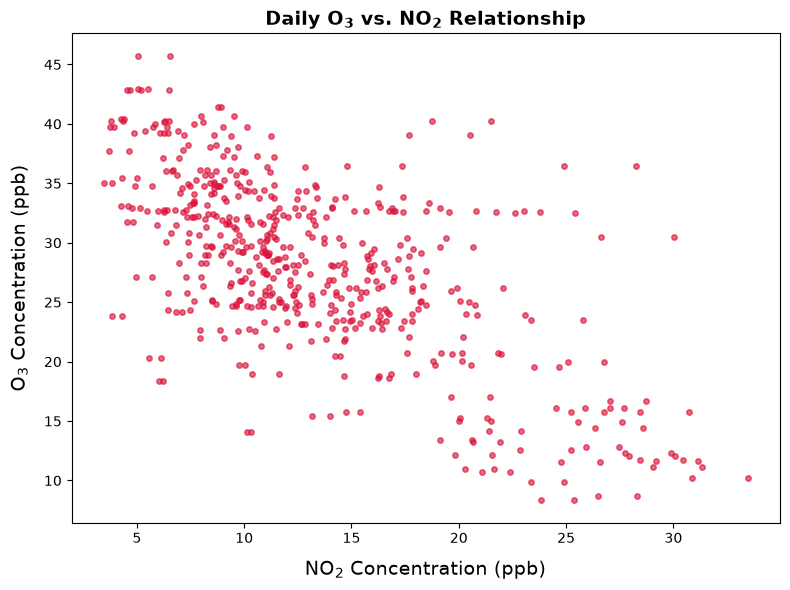

In [14]:
fig, ax = plt.subplots(figsize=(8, 6))

# Plot NO2 vs Ozone using your merged dataframe columns
ax.scatter(df_no2_o3['no2_ppb'], df_no2_o3['o3_ppb'], alpha=0.4, s=15, color="crimson")

# Set clean labels and a title matching your formatting style
ax.set_xlabel(r"$\mathrm{NO_2}$ Concentration (ppb)", fontsize=14, labelpad=10)
ax.set_ylabel(r"$\mathrm{O_3}$ Concentration (ppb)", fontsize=14, labelpad=10)
ax.set_title(r"Daily $\mathbf{O_3}$ vs. $\mathbf{NO_2}$ Relationship", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [15]:
# Drop rows with NaN values in either column to prevent calculation errors
clean_data = df_no2_o3[['no2_ppb', 'o3_ppb']].dropna()

# Calculate the Pearson correlation
r, p = stats.pearsonr(clean_data['no2_ppb'], clean_data['o3_ppb'])

print(f"O3 vs NO2 Pearson correlation r = {r:.2f}  (p = {p:.2e})")


O3 vs NO2 Pearson correlation r = -0.66  (p = 1.06e-138)


O3 vs NO2 correlation data shows a strong negative correlation. It reflects that as NO2 concentrations increase, O3 concentrations tend to decrease, which appears as an upward-sloping pattern of data points from right to left on the scatter plot.

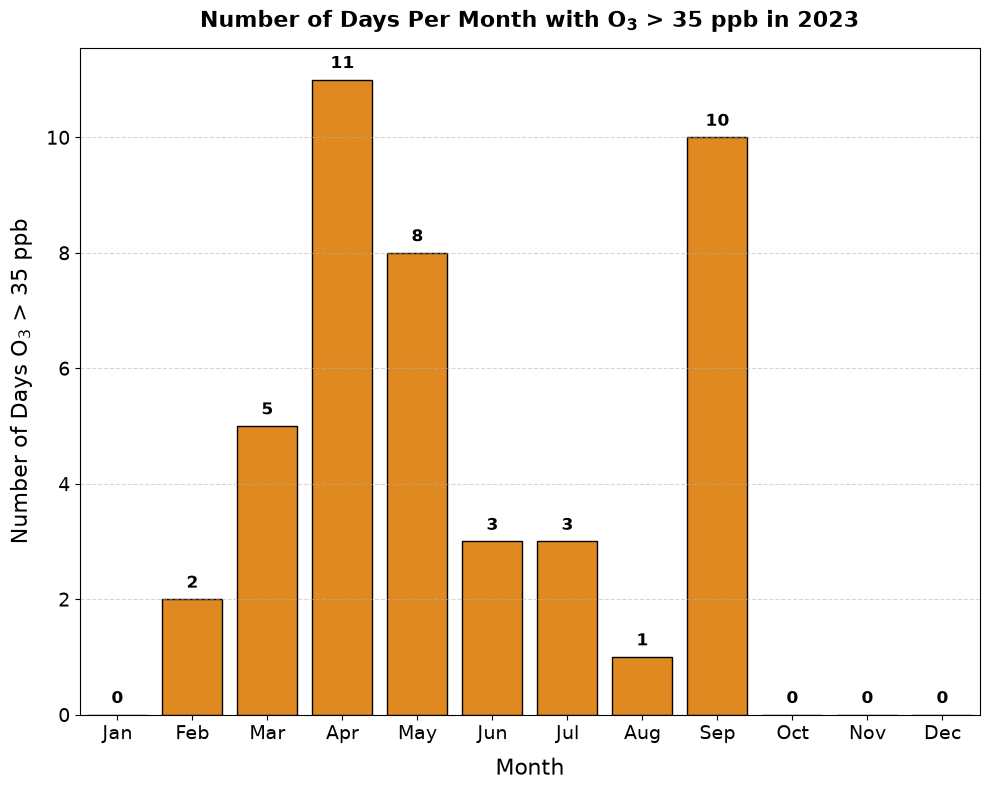

In [16]:
# 1. Convert Date column to datetime object
df_o3['Date (Local)'] = pd.to_datetime(df_o3['Date (Local)'])

# 2. Filter for 2023 data only
df_o3_2023 = df_o3[df_o3['Date (Local)'].dt.year == 2023].copy()

# 3. Create an Ozone ppb column (Arithmetic Mean * 1000)
df_o3_2023['o3_ppb'] = df_o3_2023['Arithmetic Mean'] * 1000

# 4. Extract Month name
df_o3_2023['Month'] = df_o3_2023['Date (Local)'].dt.strftime('%b')

# 5. Filter for high Ozone days (> 35 ppb)
high_o3_2023 = df_o3_2023[df_o3_2023['o3_ppb'] > 35]

# 6. Count days per month and enforce chronological calendar order
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_counts = high_o3_2023['Month'].value_counts().reindex(month_order, fill_value=0).reset_index()
monthly_counts.columns = ['Month', 'High_O3_Days']

# 7. Plot the 2023 bar chart
plt.figure(figsize=(10, 8))
sns.barplot(data=monthly_counts, x='Month', y='High_O3_Days', color='darkorange', edgecolor='black')

# Style the chart
plt.xlabel('Month', fontsize=16, labelpad=10)
plt.ylabel(r'Number of Days $\mathrm{O_3}$ > 35 ppb', fontsize=16, labelpad=10)
plt.title(r'Number of Days Per Month with $\mathbf{O_3}$ > 35 ppb in 2023', fontsize=16, fontweight='bold', pad=15)
plt.tick_params(axis='both', which='major', labelsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Add exact day labels on top of each bar
for index, row in monthly_counts.iterrows():
    plt.text(index, row['High_O3_Days'] + 0.2, str(int(row['High_O3_Days'])), 
             color='black', ha="center", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

The bar chart is showing number of days that has O3 concentration > 35 ppm in 2023. April appears to have most days (11) having higher O3, followed by september (10) while winter months have 0 days of >35 ppm O3 which makes winter air quality better than summer.

In [17]:
df= pd.read_csv('ManuaLoa_CO2.csv')

In [18]:
df.head()

,year,month,decimal date,average,deseasonalized,ndays,sdev,unc
0,1958,3,1958.2027,315.70,314.43,-1,-9.99,-0.99
1,1958,4,1958.2877,317.45,315.16,-1,-9.99,-0.99
2,1958,5,1958.3699,317.51,314.71,-1,-9.99,-0.99
3,1958,6,1958.4548,317.24,315.14,-1,-9.99,-0.99
4,1958,7,1958.5370,315.86,315.18,-1,-9.99,-0.99


In [19]:
df_co2 = df['average']
df_co2.head()

0    315.70
1    317.45
2    317.51
3    317.24
4    315.86
Name: average, dtype: float64

In [20]:
columns_list = ['decimal date','average']
df_subset = df[columns_list]
df_subset.head()

,decimal date,average
0,1958.2027,315.70
1,1958.2877,317.45
2,1958.3699,317.51
3,1958.4548,317.24
4,1958.5370,315.86


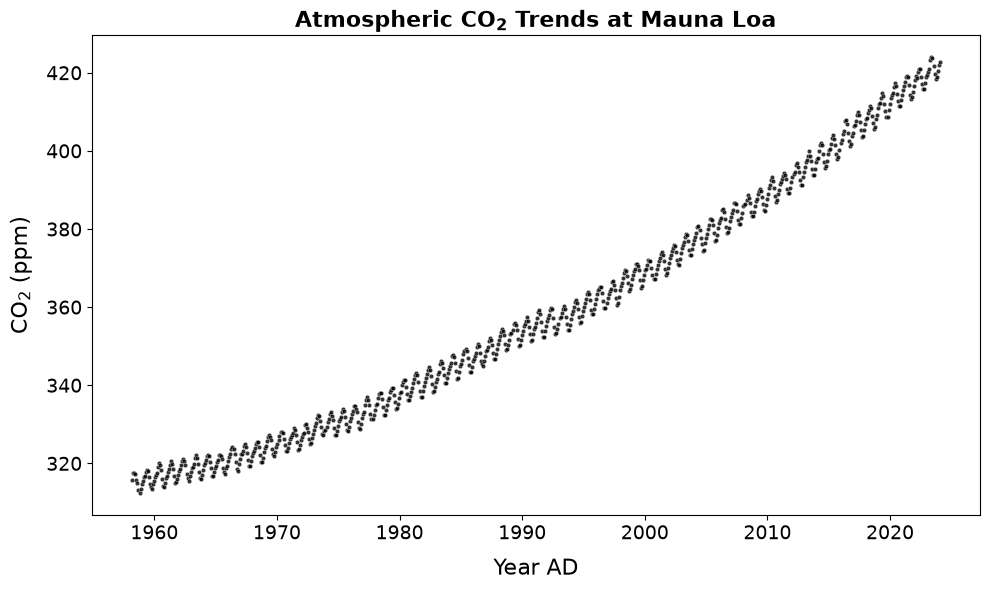

In [21]:
# create a figure and axis object to plot on
fig, ax = plt.subplots(figsize=(10,6))

# we need to specify x-axis and y-axis data
x_data = df_subset["decimal date"] 
y_data = df_subset["average"]

# Plotting with Seaborn
sns.scatterplot(x= x_data, y= y_data, alpha=0.8, s=10, color='black')

# add axis labels and a title
plt.xlabel('Year AD', fontsize= 16, labelpad=10)
plt.ylabel(r'$\mathrm{CO_2}$ (ppm)', fontsize= 16, labelpad=10)
plt.title(r'Atmospheric $\mathbf{CO_2}$ Trends at Mauna Loa', fontsize= 16, fontweight= 'bold')
plt.tick_params(axis='both', which='major', labelsize=14)

#show
plt.tight_layout()
plt.show()

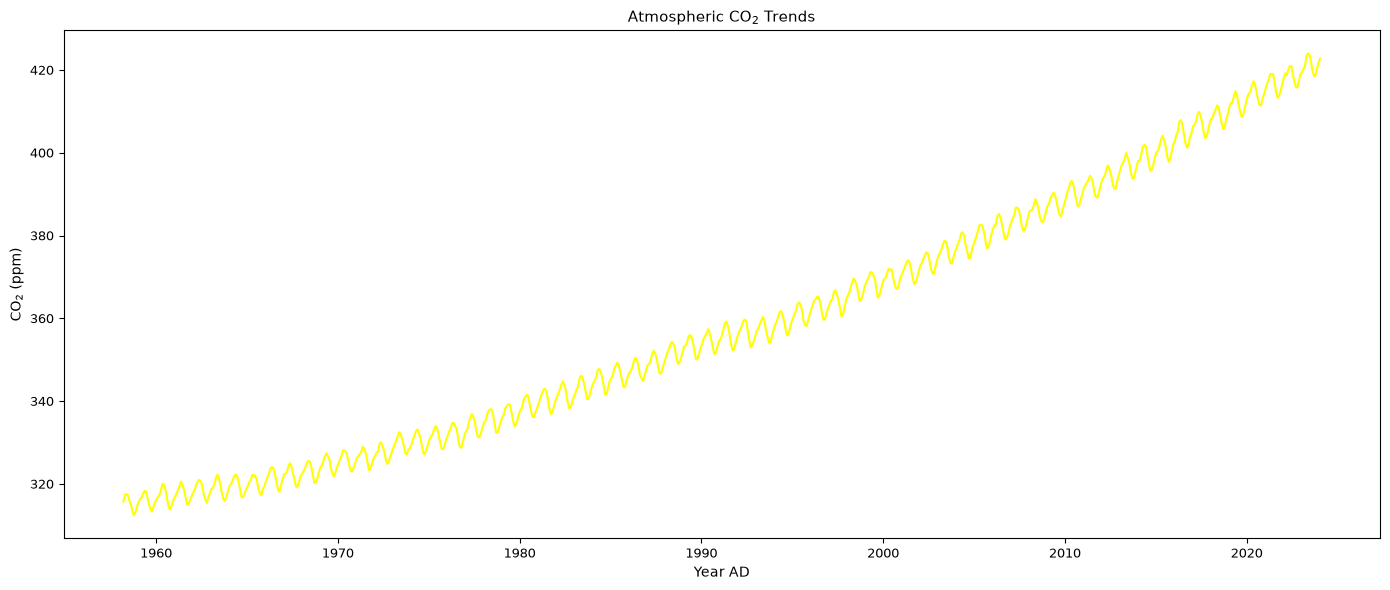

In [22]:
# Making the worst possible plot

fig, ax = plt.subplots(figsize=(14,6))

# we need to specify x-axis and y-axis data
x_data = df_subset["decimal date"] 
y_data = df_subset["average"]

# now we can plot the data
plt.plot(x_data, y_data, color='yellow')

# add axis labels and a title
plt.xlabel('Year AD', fontsize= 10)
plt.ylabel(r'$\mathrm{CO_2}$ (ppm)', fontsize= 10)
plt.title(r'Atmospheric $\mathrm{CO_2}$ Trends', fontsize= 11)
plt.tick_params(axis='both', which='major', labelsize=9)

#save and show
plt.tight_layout()
plt.show()